In [1]:
%matplotlib inline
%load_ext autoreload
%autoreload 2

In [2]:
import numpy as np
import matplotlib.pyplot as plt

from helpr.api import CrackEvolutionAnalysis
from helpr.utilities.unit_conversion import convert_psi_to_mpa, convert_in_to_m
from helpr.utilities.plots import (plot_cycle_life_cdfs, plot_cycle_life_pdfs, plot_cycle_life_criteria_scatter,
                                   plot_pipe_life_ensemble, failure_assessment_diagram_equation)
from helpr.utilities.unit_conversion import convert_in_to_m, convert_ksi_to_mpa
import probabilistic.capabilities.uncertainty_definitions as Uncertainty
from probabilistic.capabilities.plotting import plot_sample_histogram

## **Demonstration of FAD Intersection as Additional Tracked QoI**

####  **Problem Specification**

In [3]:
outer_diameter = \
    Uncertainty.UniformDistribution(name='outer_diameter',
                                    uncertainty_type='aleatory',
                                    nominal_value=convert_in_to_m(22),
                                    lower_bound=convert_in_to_m(21.9),
                                    upper_bound=convert_in_to_m(22.1))
wall_thickness = \
    Uncertainty.UniformDistribution(name='wall_thickness',
                                    uncertainty_type='aleatory',
                                    nominal_value=convert_in_to_m(0.281),
                                    lower_bound=convert_in_to_m(0.271),
                                    upper_bound=convert_in_to_m(0.291))
flaw_depth = \
    Uncertainty.TruncatedLognormalDistribution(name='flaw_depth',
                                               uncertainty_type='aleatory',
                                               nominal_value=25,
                                               mu=3.2,
                                               sigma=.17,
                                               upper_bound=80,
                                               lower_bound=0.001)
max_pressure = \
    Uncertainty.TruncatedNormalDistribution(name='max_pressure',
                                            uncertainty_type='aleatory',
                                            nominal_value=convert_psi_to_mpa(840),
                                            mean=convert_psi_to_mpa(850),
                                            std_deviation=convert_psi_to_mpa(20),
                                            lower_bound=convert_psi_to_mpa(850)-3*convert_psi_to_mpa(20),
                                            upper_bound=convert_psi_to_mpa(850)+3*convert_psi_to_mpa(20))
min_pressure = \
    Uncertainty.TruncatedNormalDistribution(name='min_pressure',
                                            uncertainty_type='aleatory',
                                            nominal_value=convert_psi_to_mpa(638),
                                            mean=convert_psi_to_mpa(638),
                                            std_deviation=convert_psi_to_mpa(20),
                                            lower_bound=convert_psi_to_mpa(638)-3*convert_psi_to_mpa(20),
                                            upper_bound=convert_psi_to_mpa(638)+3*convert_psi_to_mpa(20))

temperature = \
    Uncertainty.UniformDistribution(name='temperature',
                                    uncertainty_type='aleatory',
                                    nominal_value=293,
                                    upper_bound=300,
                                    lower_bound=285)
volume_fraction_h2 = \
    Uncertainty.DeterministicCharacterization(name='volume_fraction_h2',
                                              value=1)
yield_strength = \
    Uncertainty.DeterministicCharacterization(name='yield_strength',
                                              value=convert_psi_to_mpa(52_000))
fracture_resistance = \
    Uncertainty.DeterministicCharacterization(name='fracture_resistance',
                                                value=55)
flaw_length = \
    Uncertainty.DeterministicCharacterization(name='flaw_length',
                                                value=0.04)

folder_path = 'temp/'
samples = 50
sample_type = 'lhs'

####  **Evolve Crack Using Anderson K Solution with Proportional C Growth**

In [4]:
stress_intensity_model = 'anderson'
surface = 'inside'
delta_c_rule = 'proportional'

anderson_study = \
    CrackEvolutionAnalysis(outer_diameter=outer_diameter,
                            wall_thickness=wall_thickness,
                            flaw_depth=flaw_depth,
                            max_pressure=max_pressure,
                            min_pressure=min_pressure,
                            temperature=temperature,
                            volume_fraction_h2=volume_fraction_h2,
                            yield_strength=yield_strength,
                            fracture_resistance=fracture_resistance,
                            flaw_length=flaw_length,
                            sample_type=sample_type,
                            aleatory_samples=samples,
                            stress_intensity_method=stress_intensity_model,
                            surface=surface,
                            delta_c_rule=delta_c_rule,
                            fad_type='API 579-1 Level 2')
anderson_study.perform_study()

/Users/bbschro/Development/helpr_external/src/helpr/physics/stress_state.py:521: UserWarning: Inner Radius / wall thickness exceeds bounds 5 <= R_i/t <= 20, R_i/t = 38.1459074733096, violating Anderson solution limits.
  wr.warn('Inner Radius / wall thickness exceeds bounds ' +
/Users/bbschro/Development/helpr_external/src/helpr/physics/stress_state.py:521: UserWarning: Inner Radius / wall thickness exceeds bounds 5 <= R_i/t <= 20, R_i/t = 37.4527467027715, violating Anderson solution limits.
  wr.warn('Inner Radius / wall thickness exceeds bounds ' +
/Users/bbschro/Development/helpr_external/src/helpr/physics/stress_state.py:521: UserWarning: Inner Radius / wall thickness exceeds bounds 5 <= R_i/t <= 20, R_i/t = 36.91953124051927, violating Anderson solution limits.
  wr.warn('Inner Radius / wall thickness exceeds bounds ' +
/Users/bbschro/Development/helpr_external/src/helpr/physics/stress_state.py:521: UserWarning: Inner Radius / wall thickness exceeds bounds 5 <= R_i/t <= 20, R_i/t

####  **Evolve Crack Using API 579-1 K Solution with Proporaitonal C Growth**

In [5]:
stress_intensity_model = 'api'
surface = 'inside'
delta_c_rule = 'proportional'

api_prop_study = \
    CrackEvolutionAnalysis(outer_diameter=outer_diameter,
                            wall_thickness=wall_thickness,
                            flaw_depth=flaw_depth,
                            max_pressure=max_pressure,
                            min_pressure=min_pressure,
                            temperature=temperature,
                            volume_fraction_h2=volume_fraction_h2,
                            yield_strength=yield_strength,
                            fracture_resistance=fracture_resistance,
                            flaw_length=flaw_length,
                            sample_type=sample_type,
                            aleatory_samples=samples,
                            stress_intensity_method=stress_intensity_model,
                            surface=surface,
                            delta_c_rule=delta_c_rule,
                            fad_type='API 579-1 Level 2')
api_prop_study.perform_study()

####  **Evolve Crack Using API 579-1 K Solution with Independent C Growth**

In [6]:
stress_intensity_model = 'api'
surface = 'inside'
delta_c_rule = 'independent'

api_ind_study = \
    CrackEvolutionAnalysis(outer_diameter=outer_diameter,
                            wall_thickness=wall_thickness,
                            flaw_depth=flaw_depth,
                            max_pressure=max_pressure,
                            min_pressure=min_pressure,
                            temperature=temperature,
                            volume_fraction_h2=volume_fraction_h2,
                            yield_strength=yield_strength,
                            fracture_resistance=fracture_resistance,
                            flaw_length=flaw_length,
                            sample_type=sample_type,
                            aleatory_samples=samples,
                            stress_intensity_method=stress_intensity_model,
                            surface=surface,
                            delta_c_rule=delta_c_rule,
                            fad_type='API 579-1 Level 2')
api_ind_study.perform_study()

/Users/bbschro/Development/helpr_external/src/helpr/utilities/postprocessing.py:363: UserWarning: Kmax + Kres did not reach fracture resistance for at least one crack, setting a_crit/t = 0.8 for such cracks
  wr.warn('Kmax + Kres did not reach fracture resistance for at least one crack, ' +


####  **Evolve Crack Using API 579-1 K Solution with Independent C Growth for External Crack**

In [7]:
stress_intensity_model = 'api'
surface = 'outside'
delta_c_rule = 'independent'

api_ind_out_study = \
    CrackEvolutionAnalysis(outer_diameter=outer_diameter,
                            wall_thickness=wall_thickness,
                            flaw_depth=flaw_depth,
                            max_pressure=max_pressure,
                            min_pressure=min_pressure,
                            temperature=temperature,
                            volume_fraction_h2=volume_fraction_h2,
                            yield_strength=yield_strength,
                            fracture_resistance=fracture_resistance,
                            flaw_length=flaw_length,
                            sample_type=sample_type,
                            aleatory_samples=samples,
                            stress_intensity_method=stress_intensity_model,
                            surface=surface,
                            delta_c_rule=delta_c_rule,
                            fad_type='API 579-1 Level 2')
api_ind_out_study.perform_study()

/Users/bbschro/Development/helpr_external/src/helpr/utilities/postprocessing.py:363: UserWarning: Kmax + Kres did not reach fracture resistance for at least one crack, setting a_crit/t = 0.8 for such cracks
  wr.warn('Kmax + Kres did not reach fracture resistance for at least one crack, ' +


####  **Evolve Crack Using API 579-1 K Solution with Fixed C**

In [8]:
stress_intensity_model = 'api'
surface = 'inside'
delta_c_rule = 'fixed'

api_fixed_study = \
    CrackEvolutionAnalysis(outer_diameter=outer_diameter,
                            wall_thickness=wall_thickness,
                            flaw_depth=flaw_depth,
                            max_pressure=max_pressure,
                            min_pressure=min_pressure,
                            temperature=temperature,
                            volume_fraction_h2=volume_fraction_h2,
                            yield_strength=yield_strength,
                            fracture_resistance=fracture_resistance,
                            flaw_length=flaw_length,
                            sample_type=sample_type,
                            aleatory_samples=samples,
                            stress_intensity_method=stress_intensity_model,
                            surface=surface,
                            delta_c_rule=delta_c_rule,
                            fad_type='API 579-1 Level 2')
api_fixed_study.perform_study()

/Users/bbschro/Development/helpr_external/src/helpr/utilities/postprocessing.py:363: UserWarning: Kmax + Kres did not reach fracture resistance for at least one crack, setting a_crit/t = 0.8 for such cracks
  wr.warn('Kmax + Kres did not reach fracture resistance for at least one crack, ' +


####  **FAD Line Equations**

In [9]:
def failure_assessment_diagram_equation(load_ratio):
    """Calculates line from FAD equation. 
    Eq. 9.22 on page 9-61 of API 579-1/ASME FFS-1, June, 2016 Fitness-For-Service"""
    toughness_ratio = (1 - 0.14 * load_ratio**2) * (0.3 + 0.7 * np.exp(-0.65 * load_ratio**6))
    return toughness_ratio

def failure_assessment_diagram_equation_v2(load_ratio):
    """Calculates line from FAD equation. 
    Eq. supposed to be in API 579 2021 Fitness-For-Service"""
    toughness_ratio = (1 + load_ratio**2/2)**(-1/2) * (0.3 + 0.7 * np.exp(-0.6 * load_ratio**6))
    return toughness_ratio

####  **Plot of FAD Lines**

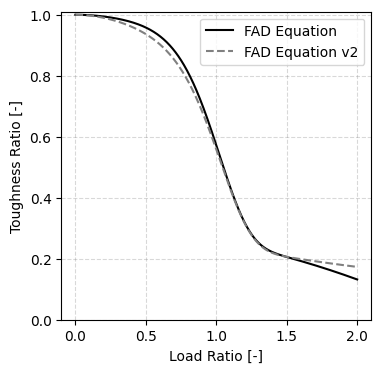

In [10]:
# Generate load ratios for the FAD equation
load_ratios = np.linspace(0, 2, 1000)
fad_values = failure_assessment_diagram_equation(load_ratios)
fad_values_v2 = failure_assessment_diagram_equation_v2(load_ratios)

plt.figure(figsize=(4, 4))

# Plot of FAD curve and data intersection point
plt.plot(load_ratios, fad_values, label='FAD Equation', color='black')
plt.plot(load_ratios, fad_values_v2, label='FAD Equation v2', color='gray', linestyle='--')
plt.xlabel('Load Ratio [-]')
plt.ylabel('Toughness Ratio [-]')
plt.ylim(0, 1.01)
plt.legend(loc='best')
plt.grid(alpha=0.3, color='gray', linestyle='--')

####  **Plot of FAD Intersections and Crack Evolutions**

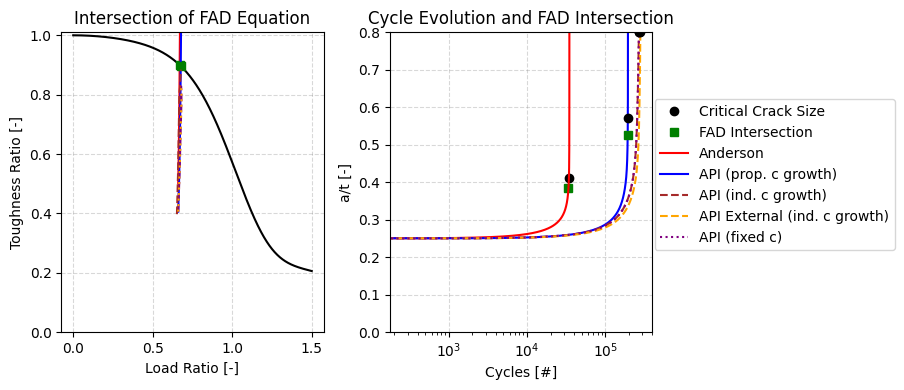

In [11]:
# Generate load ratios for the FAD equation
load_ratios = np.linspace(0, 1.5, 1000)
fad_values = failure_assessment_diagram_equation(load_ratios)

# Create subplots: 1 row, 2 columns
fig, axs = plt.subplots(1, 2, figsize=(10, 4))

# Plot of FAD curve and data intersection point
axs[0].plot(load_ratios, fad_values, label='FAD Equation', color='black')

axs[0].plot(anderson_study.nominal_load_cycling[0]['Load ratio'],
            anderson_study.nominal_load_cycling[0]['Toughness ratio'],
            'r-', label='Anderson')
axs[0].plot(anderson_study.nominal_life_criteria['Cycles to FAD line'][2],
            anderson_study.nominal_life_criteria['Cycles to FAD line'][3],
            'gs', label='Intersection Point')

axs[0].plot(api_prop_study.nominal_load_cycling[0]['Load ratio'],
            api_prop_study.nominal_load_cycling[0]['Toughness ratio'],
            color='blue', linestyle='-', label='API (prop. c growth)')
axs[0].plot(api_prop_study.nominal_life_criteria['Cycles to FAD line'][2],
            api_prop_study.nominal_life_criteria['Cycles to FAD line'][3],
            'gs')

axs[0].plot(api_ind_study.nominal_load_cycling[0]['Load ratio'],
            api_ind_study.nominal_load_cycling[0]['Toughness ratio'],
            color='purple', linestyle='--', label='API (ind. c growth)')
axs[0].plot(api_ind_study.nominal_life_criteria['Cycles to FAD line'][2],
            api_ind_study.nominal_life_criteria['Cycles to FAD line'][3],
            'gs')

axs[0].plot(api_ind_out_study.nominal_load_cycling[0]['Load ratio'],
            api_ind_out_study.nominal_load_cycling[0]['Toughness ratio'],
            color='brown', linestyle='--', label='API external (ind. c growth)')
axs[0].plot(api_ind_out_study.nominal_life_criteria['Cycles to FAD line'][2],
            api_ind_out_study.nominal_life_criteria['Cycles to FAD line'][3],
            'gs')

axs[0].plot(api_fixed_study.nominal_load_cycling[0]['Load ratio'],
            api_fixed_study.nominal_load_cycling[0]['Toughness ratio'],
            color='orange', linestyle=':', label='API (fixed c)')
axs[0].plot(api_fixed_study.nominal_life_criteria['Cycles to FAD line'][2],
            api_fixed_study.nominal_life_criteria['Cycles to FAD line'][3],
            'gs')

axs[0].set_title('Intersection of FAD Equation')
axs[0].set_xlabel('Load Ratio [-]')
axs[0].set_ylabel('Toughness Ratio [-]')
axs[0].set_ylim(0, 1.01)
#axs[0].legend(loc='best')
axs[0].grid(alpha=0.3, color='gray', linestyle='--')


# Plot of cycle evolution and when FAD intersection occurs
axs[1].plot(anderson_study.nominal_life_criteria['Cycles to a(crit)'][0][0],
            anderson_study.nominal_life_criteria['Cycles to a(crit)'][1][0],
            'ko', label='Critical Crack Size')
axs[1].plot(anderson_study.nominal_life_criteria['Cycles to FAD line'][0],
            anderson_study.nominal_life_criteria['Cycles to FAD line'][1],
            'gs', label='FAD Intersection')
axs[1].plot(anderson_study.nominal_load_cycling[0]['Total cycles'],
            anderson_study.nominal_load_cycling[0]['a/t'],
            'r-', label='Anderson')

axs[1].plot(api_prop_study.nominal_load_cycling[0]['Total cycles'],
            api_prop_study.nominal_load_cycling[0]['a/t'],
            'b-', label='API (prop. c growth)')
axs[1].plot(api_prop_study.nominal_life_criteria['Cycles to a(crit)'][0][0],
            api_prop_study.nominal_life_criteria['Cycles to a(crit)'][1][0],
            'ko')
axs[1].plot(api_prop_study.nominal_life_criteria['Cycles to FAD line'][0],
            api_prop_study.nominal_life_criteria['Cycles to FAD line'][1],
            'gs')

axs[1].plot(api_ind_study.nominal_load_cycling[0]['Total cycles'],
            api_ind_study.nominal_load_cycling[0]['a/t'],
            color='brown', linestyle='--', label='API (ind. c growth)')
axs[1].plot(api_ind_study.nominal_life_criteria['Cycles to a(crit)'][0][0],
            api_ind_study.nominal_life_criteria['Cycles to a(crit)'][1][0],
            'ko')
axs[1].plot(api_ind_study.nominal_life_criteria['Cycles to FAD line'][0],
            api_ind_study.nominal_life_criteria['Cycles to FAD line'][1],
            'gs')

axs[1].plot(api_ind_out_study.nominal_load_cycling[0]['Total cycles'],
            api_ind_out_study.nominal_load_cycling[0]['a/t'],
            color='orange', linestyle='--', label='API External (ind. c growth)')
axs[1].plot(api_ind_out_study.nominal_life_criteria['Cycles to a(crit)'][0][0],
            api_ind_out_study.nominal_life_criteria['Cycles to a(crit)'][1][0],
            'ko')
axs[1].plot(api_ind_out_study.nominal_life_criteria['Cycles to FAD line'][0],
            api_ind_out_study.nominal_life_criteria['Cycles to FAD line'][1],
            'gs')

axs[1].plot(api_fixed_study.nominal_load_cycling[0]['Total cycles'],
            api_fixed_study.nominal_load_cycling[0]['a/t'],
            color='purple', linestyle=':', label='API (fixed c)')
axs[1].plot(api_fixed_study.nominal_life_criteria['Cycles to a(crit)'][0][0],
            api_fixed_study.nominal_life_criteria['Cycles to a(crit)'][1][0],
            'ko')
axs[1].plot(api_fixed_study.nominal_life_criteria['Cycles to FAD line'][0],
            api_fixed_study.nominal_life_criteria['Cycles to FAD line'][1],
            'gs')

axs[1].set_title('Cycle Evolution and FAD Intersection')
axs[1].set_xlabel('Cycles [#]')
axs[1].set_ylabel('a/t [-]')
#axs[1].legend(loc='best')
axs[1].legend(loc='upper right', bbox_to_anchor=(1.95, 0.8))
axs[1].set_ylim(0, 0.8)
axs[1].grid(alpha=0.3, color='gray', linestyle='--')
axs[1].set_xscale('log')

# Adjust layout to prevent overlap
plt.tight_layout()

####  **Plot of Crack Depth (a) and Length (c) Growth Given Different Assumptions**

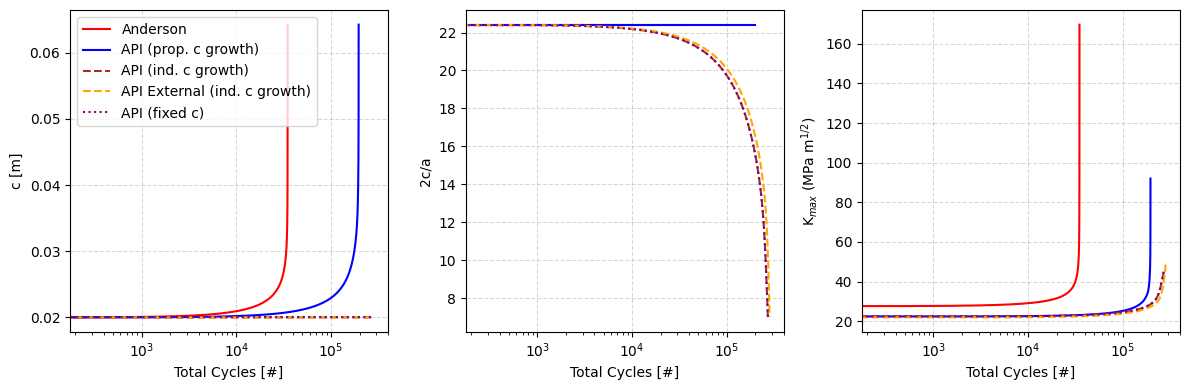

In [12]:
# Create subplots: 1 row, 3 columns
fig, axs = plt.subplots(1, 3, figsize=(12, 4))

axs[0].plot(anderson_study.nominal_load_cycling[0]['Total cycles'],
         anderson_study.nominal_load_cycling[0]['c (m)'],
         'r-', label='Anderson')

axs[0].plot(api_prop_study.nominal_load_cycling[0]['Total cycles'],
            api_prop_study.nominal_load_cycling[0]['c (m)'],
            'b-', label='API (prop. c growth)')

axs[0].plot(api_ind_study.nominal_load_cycling[0]['Total cycles'],
            api_ind_study.nominal_load_cycling[0]['c (m)'],
            color='brown', linestyle='--', label='API (ind. c growth)')

axs[0].plot(api_ind_out_study.nominal_load_cycling[0]['Total cycles'],
            api_ind_out_study.nominal_load_cycling[0]['c (m)'],
            color='orange', linestyle='--', label='API External (ind. c growth)')

axs[0].plot(api_fixed_study.nominal_load_cycling[0]['Total cycles'],
            api_fixed_study.nominal_load_cycling[0]['c (m)'],
            color='purple', linestyle=':', label='API (fixed c)')

axs[0].set_xlabel('Total Cycles [#]')
axs[0].set_ylabel('c [m]')
axs[0].grid(alpha=0.3, color='gray', linestyle='--')
axs[0].set_xscale('log')
axs[0].legend(loc=0)


axs[1].plot(anderson_study.nominal_load_cycling[0]['Total cycles'],
         2*np.array(anderson_study.nominal_load_cycling[0]['c (m)'])\
            /np.array(anderson_study.nominal_load_cycling[0]['a (m)']),
         'r-', label='Anderson')

axs[1].plot(api_prop_study.nominal_load_cycling[0]['Total cycles'],
         2*np.array(api_prop_study.nominal_load_cycling[0]['c (m)'])\
            /np.array(api_prop_study.nominal_load_cycling[0]['a (m)']),
         'b-', label='API (prop. c growth)')

axs[1].plot(api_ind_study.nominal_load_cycling[0]['Total cycles'],
         2*np.array(api_ind_study.nominal_load_cycling[0]['c (m)'])\
            /np.array(api_ind_study.nominal_load_cycling[0]['a (m)']),
         color='brown', linestyle='--', label='API (ind. c growth)')

axs[1].plot(api_ind_out_study.nominal_load_cycling[0]['Total cycles'],
         2*np.array(api_ind_out_study.nominal_load_cycling[0]['c (m)'])\
            /np.array(api_ind_out_study.nominal_load_cycling[0]['a (m)']),
         color='orange', linestyle='--', label='API External (ind. c growth)')

axs[1].plot(api_fixed_study.nominal_load_cycling[0]['Total cycles'],
         2*np.array(api_fixed_study.nominal_load_cycling[0]['c (m)'])\
            /np.array(api_fixed_study.nominal_load_cycling[0]['a (m)']),
         color='purple', linestyle=':', label='API (fixed c)')

axs[1].set_xlabel('Total Cycles [#]')
axs[1].set_ylabel('2c/a')
axs[1].grid(alpha=0.3, color='gray', linestyle='--')
axs[1].set_xscale('log')


axs[2].plot(anderson_study.nominal_load_cycling[0]['Total cycles'],
            anderson_study.nominal_load_cycling[0]['Kmax (MPa m^1/2)'],
            'r-', label='Anderson')

axs[2].plot(api_prop_study.nominal_load_cycling[0]['Total cycles'],
            api_prop_study.nominal_load_cycling[0]['Kmax (MPa m^1/2)'],
            'b-', label='API (prop. c growth)')

axs[2].plot(api_ind_study.nominal_load_cycling[0]['Total cycles'],
            api_ind_study.nominal_load_cycling[0]['Kmax (MPa m^1/2)'],
            color='brown', linestyle='--', label='API (ind. c growth)')

axs[2].plot(api_ind_out_study.nominal_load_cycling[0]['Total cycles'],
            api_ind_out_study.nominal_load_cycling[0]['Kmax (MPa m^1/2)'],
         color='orange', linestyle='--', label='API External (ind. c growth)')

axs[2].plot(api_fixed_study.nominal_load_cycling[0]['Total cycles'],
            api_fixed_study.nominal_load_cycling[0]['Kmax (MPa m^1/2)'],
            color='purple', linestyle=':', label='API (fixed c)')

axs[2].set_xlabel('Total Cycles [#]')
axs[2].set_ylabel('K$_{max}$ (MPa m$^{1/2}$)')
axs[2].grid(alpha=0.3, color='gray', linestyle='--')
axs[2].set_xscale('log')

# # Adjust layout to prevent overlap
plt.tight_layout();


####  **Plots Comparing Probabilistic FAD Instersection QoI w/ Critical Crack Size**

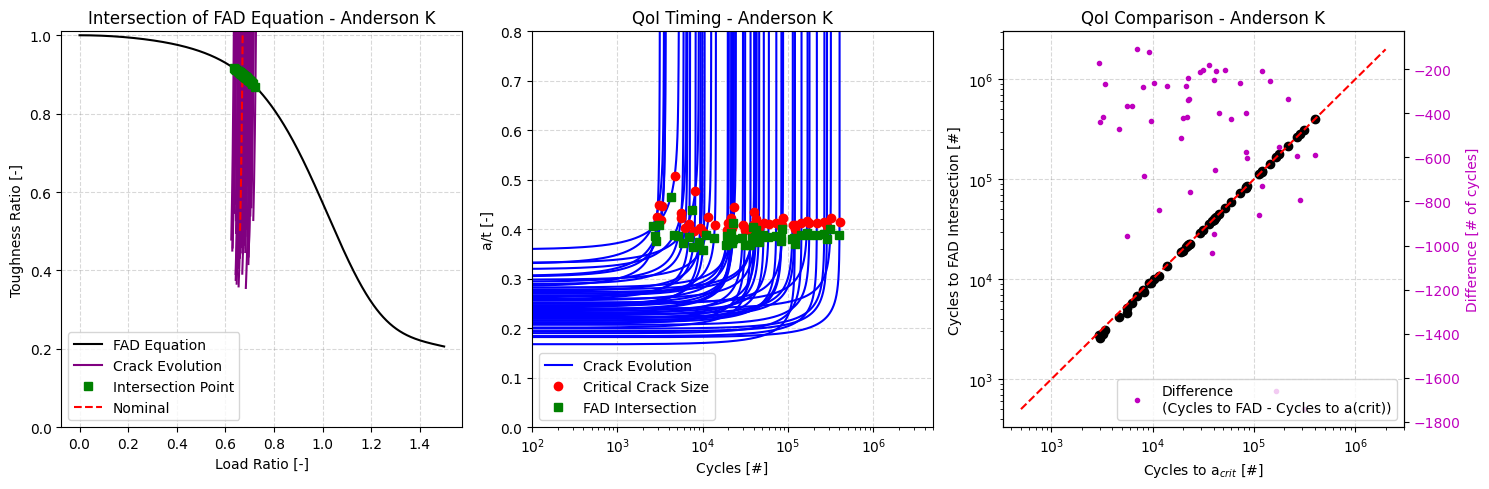

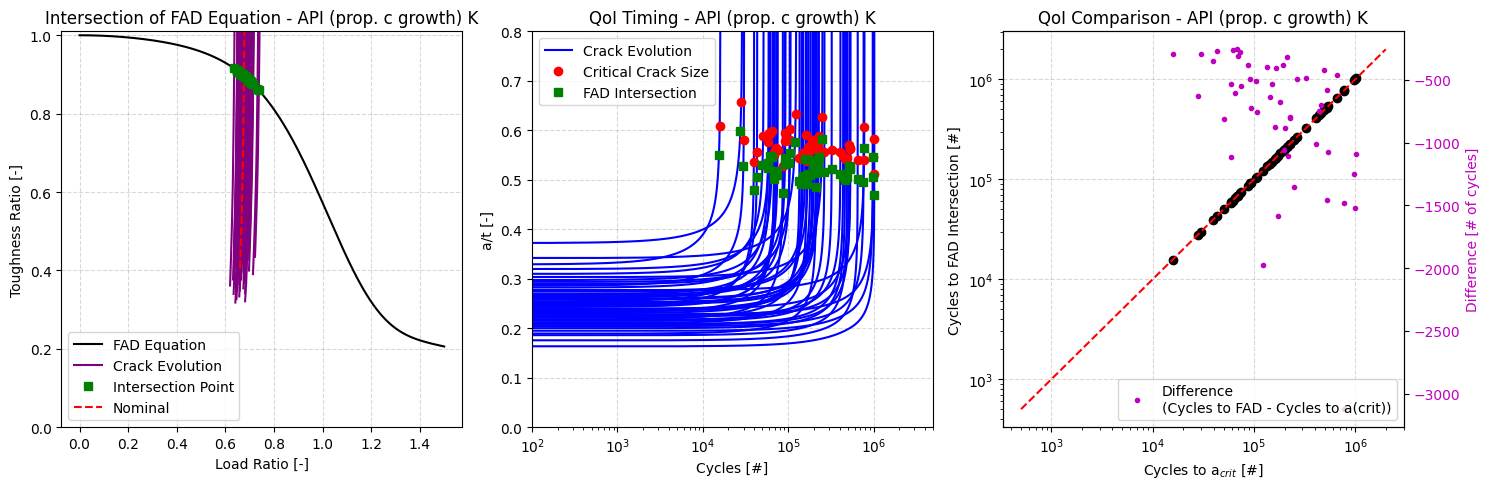

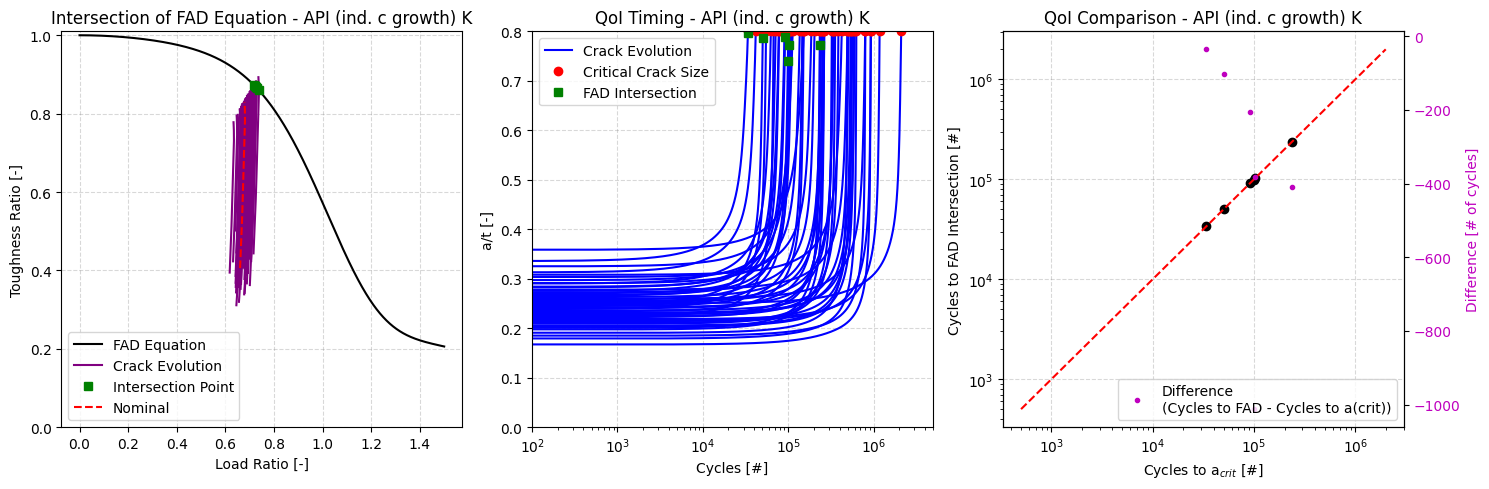

In [13]:
# Define a list of intersection data for each dataset
data_sets = [anderson_study,
             api_prop_study,
             api_ind_study]
dataset_labels = ['Anderson',
                  'API (prop. c growth)',
                  'API (ind. c growth)']

for data_set, label in zip(data_sets, dataset_labels):
    # Create subplots: 1 row, 3 columns
    fig, axs = plt.subplots(1, 3, figsize=(15, 5))

    # Plot of FAD curve and data intersection points for each dataset
    ax = axs[0]
    ax.plot(load_ratios, fad_values, label='FAD Equation', color='black')

    # Placeholder for legend entries
    ax.plot([], [], color='purple', linestyle='-', label='Crack Evolution')
    ax.plot([], [], 'gs', label='Intersection Point')

    for i in range(data_set.study.total_sample_size):
        load_ratio_data = np.array(data_set.load_cycling[i]['Load ratio'])
        toughness_ratio_data = np.array(data_set.load_cycling[i]['Toughness ratio'])
        ax.plot(load_ratio_data, toughness_ratio_data, color='purple', linestyle='-')

    ax.plot(data_set.nominal_load_cycling[0]['Load ratio'],
            data_set.nominal_load_cycling[0]['Toughness ratio'],
            color='red', linestyle='--', label='Nominal')
    
    # Plot intersection point for the current dataset
    ax.plot(data_set.life_criteria['Cycles to FAD line'][2],
            data_set.life_criteria['Cycles to FAD line'][3],
            'gs')

    ax.set_title(f'Intersection of FAD Equation - {label} K')
    ax.set_xlabel('Load Ratio [-]')
    ax.set_ylabel('Toughness Ratio [-]')
    ax.set_ylim(0, 1.01)
    ax.legend(loc='best')
    ax.grid(alpha=0.3, color='gray', linestyle='--')

    # Plot of cycle evolution and when FAD intersection occurs
    ax = axs[1]  # Use the second subplot for cycle evolution
    ax.plot([], [], 'b-', label='Crack Evolution')
    ax.plot([], [], 'ro', label='Critical Crack Size')
    ax.plot([], [], 'gs', label='FAD Intersection')

    for i in range(data_set.study.total_sample_size):    
        cycles = np.array(data_set.load_cycling[i]['Total cycles'])
        a_over_t = np.array(data_set.load_cycling[i]['a/t'])
        ax.plot(cycles, a_over_t, 'b-')
        
    # Critical crack size and cycles to reach it
    a_crit_over_t = data_set.life_criteria['Cycles to a(crit)'][1]
    cycles_to_a_crit = data_set.life_criteria['Cycles to a(crit)'][0]
    ax.plot(cycles_to_a_crit, a_crit_over_t, 'ro')

    # Plot FAD intersection for the current dataset
    ax.plot(data_set.life_criteria['Cycles to FAD line'][0],
            data_set.life_criteria['Cycles to FAD line'][1],
            'gs')

    ax.set_title(f'QoI Timing - {label} K')
    ax.set_xlabel('Cycles [#]')
    ax.set_ylabel('a/t [-]')
    ax.legend(loc='best')
    ax.set_xlim(1e2, 5e6)
    ax.set_ylim(0, 0.8)
    ax.set_xscale('log')
    ax.grid(alpha=0.3, color='gray', linestyle='--')

    # Plot Comparing Cycles Critical Crack Size and FAD Intersection
    ax = axs[2]  # Use the third subplot for comparing cycles
    for i in range(data_set.study.total_sample_size): 
        cycles_to_a_crit = data_set.life_criteria['Cycles to a(crit)'][0][i]
        # cycles_to_fad_intersection = intersection_info[i]['cycles_fad_criteria']
        cycles_to_fad_intersection = data_set.life_criteria['Cycles to FAD line'][0][i]
        ax.plot(cycles_to_a_crit, cycles_to_fad_intersection, 'ko')

    # Add a diagonal line with slope 1
    x_values = np.logspace(2.7, 6.3, 2)
    ax.plot(x_values, x_values, 'r--')

    ax.set_title(f'QoI Comparison - {label} K')
    ax.set_xlabel('Cycles to a$_{crit}$ [#]')
    ax.set_ylabel('Cycles to FAD Intersection [#]')
    ax.set_xscale('log')
    ax.set_yscale('log')
    ax.grid(alpha=0.3, color='gray', linestyle='--')

    # Calculate the difference and plot on the right y-axis
    ax_diff = ax.twinx()  # Create a twin y-axis
    differences = [data_set.life_criteria['Cycles to FAD line'][0][i] -
                   data_set.life_criteria['Cycles to a(crit)'][0][i] 
                   for i in range(data_set.study.total_sample_size)]
    
    ax_diff.plot(data_set.life_criteria['Cycles to a(crit)'][0],
                 differences,
                 'm.',
                 label='Difference\n(Cycles to FAD - Cycles to a(crit))')
    ax_diff.set_ylabel('Difference [# of cycles]', color='m')
    ax_diff.tick_params(axis='y', labelcolor='m')
    ax_diff.grid(False)  # Disable grid for the twin axis
    ax_diff.legend(loc='lower right')

    # Adjust layout to prevent overlap
    plt.tight_layout()


####  **Demonstrating FAD Plot Generation Built into API**

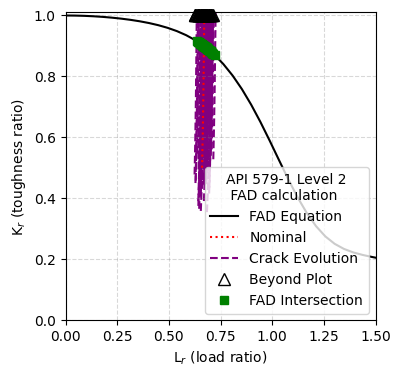

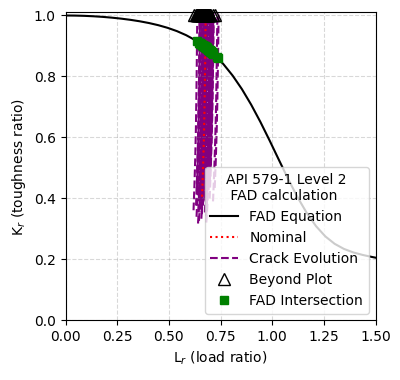

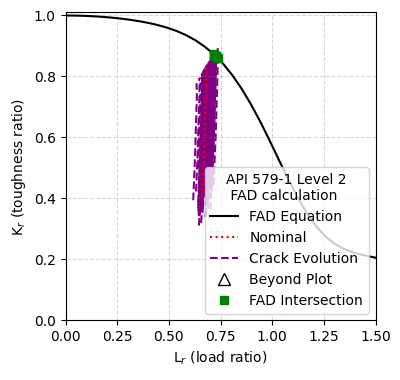

In [14]:
_ = anderson_study.assemble_failure_assessment_diagram()
_ = api_prop_study.assemble_failure_assessment_diagram()
_ = api_ind_study.assemble_failure_assessment_diagram()